### Contoh: Turunan Orde Pertama

0.8975979010256552 = 0.8975979010256552


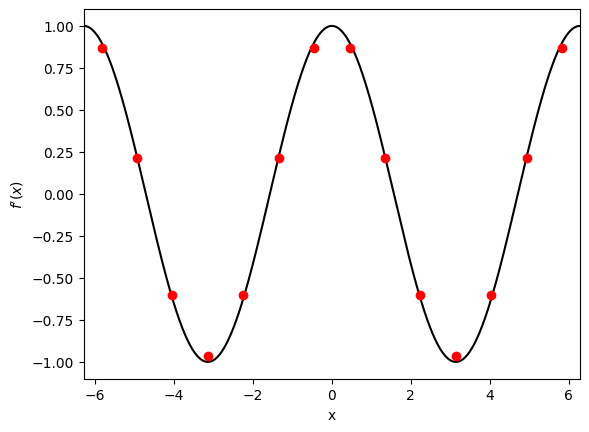

In [3]:
f = lambda x: numpy.sin(x)
f_prime = lambda x: numpy.cos(x)

# Gunakan diskritisasi seragam
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000)
N = 15
x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)
delta_x = x_hat[1] - x_hat[0]
print("%s = %s" % (delta_x, (x_hat[-1] - x_hat[0]) / (N - 1)))

# Hitung selisih maju menggunakan sebuah perulangan
f_prime_hat = numpy.empty(x_hat.shape)
for i in range(N - 1):
    f_prime_hat[i] = (f(x_hat[i+1]) - f(x_hat[i])) / delta_x
f_prime_hat[-1] = (f(x_hat[i]) - f(x_hat[i-1])) / delta_x

# Perhitungan berbasis vektor
# f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / (delta_x)

# Gunakan selisih orde pertama untuk titik-titik di tepi domain
f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x  # Selisih Mundur di x_N

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(x, f_prime(x), 'k')
axes.plot(x_hat + 0.5 * delta_x, f_prime_hat, 'ro')
axes.set_xlim((x[0], x[-1]))
axes.set_ylim((-1.1, 1.1))
axes.set_xlabel("x")
axes.set_ylabel(r"$f'(x)$")

plt.show()

### Contoh: Turunan Orde Kedua

Menggunakan pendekatan deret Taylor kita, mari kita turunkan rumus turunan kedua dengan akurasi orde kedua. Sekali lagi kita akan menggunakan titik-titik yang sama dan deret Taylor yang berpusat di $x = x_n$ sehingga kita berakhir dengan ekspresi yang sama seperti sebelumnya:

$$\begin{aligned}
    u''(x_n) + R(x_n) &= \quad A \left ( u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5)\right ) \\
    &\quad+ B u(x_n) \\
    &\quad+ C \left ( u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5) \right )
\end{aligned}$$

kecuali kali ini kita ingin menyisakan $u''(x_n)$ di sisi kanan. Melakukan trik yang sama seperti sebelumnya kita memiliki ekspresi berikut:

$$\begin{aligned}
    u(x_n): & \quad A + B + C = 0 \\
    u'(x_n): & \quad A \Delta x - C \Delta x = 0 \\
    u''(x_n): & \quad A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 1
\end{aligned}$$

Persamaan kedua mengimplikasikan $A = C$ yang dikombinasikan dengan persamaan ketiga mengimplikasikan

$$A = C = \frac{1}{\Delta x^2}$$

Terakhir persamaan pertama memberikan

$$B = -\frac{2}{\Delta x^2}$$

yang menghasilkan ekspresi akhir

$$\begin{aligned}
    u''(x_n) + R(x_n) &= \frac{u(x_{n+1}) - 2 u(x_n) + u(x_{n-1})}{\Delta x^2} \\
&\quad+ \frac{1}{\Delta x^2} \left(\frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n)  - \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n)  \right) + \mathcal{O}(\Delta x^5)
\end{aligned}$$

dengan

$$R(x_n) = \frac{\Delta x^2}{12} u^{(4)}(x_n) + \mathcal{O}(\Delta x^3)$$

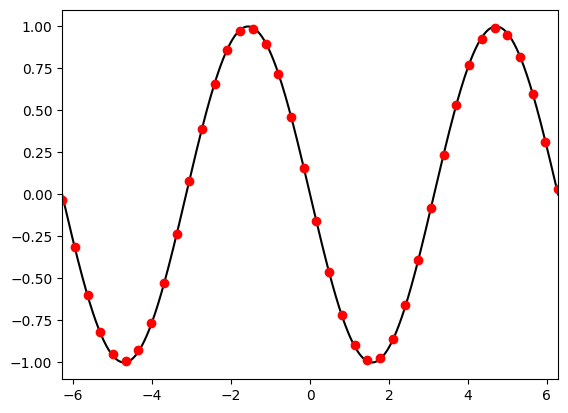

In [5]:
f = lambda x: numpy.sin(x)
f_dubl_prime = lambda x: -numpy.sin(x)

# Gunakan diskritisasi seragam
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000)
N = 40
x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)
delta_x = x_hat[1] - x_hat[0]

# Hitung turunan
f_dubl_prime_hat = numpy.empty(x_hat.shape)
f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) -2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x**2)

# Gunakan selisih orde pertama untuk titik-titik di tepi domain
f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / delta_x**2
f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / delta_x**2

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(x, f_dubl_prime(x), 'k')
axes.plot(x_hat, f_dubl_prime_hat, 'ro')
axes.set_xlim((x[0], x[-1]))
axes.set_ylim((-1.1, 1.1))

plt.show()

### Penurunan Umum

Untuk aproksimasi selisih hingga umum yang terletak di $\bar{x}$ ke turunan ke-$k$ dengan stensil sembarang $N \geq k + 1$ titik $x_1, \ldots, x_N$ kita dapat menggunakan beberapa generalisasi dari metode di atas. Perhatikan bahwa meskipun umum bahwa $\bar{x}$ adalah salah satu dari titik-titik stensil, ini tidak mutlak. Kita juga berasumsi bahwa $u(x)$ cukup mulus sehingga deret Taylor kita valid.

Pada setiap titik stensil kita memiliki aproksimasi
$$
    u(x_i) = u(\bar{x}) + (x_i - \bar{x})u'(\bar{x}) + \cdots + \frac{1}{k!}(x_i - \bar{x})^k u^{(k)}(\bar{x}) + \cdots.
$$

Mengikuti metodologi kita di atas kita ingin mencari kombinasi linier dari ekspansi deret Taylor ini sedemikian rupa sehingga
$$
    u^{(k)}(\bar{x}) + \mathcal{O}(\Delta x^p) = a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_n u(x_n).
$$
Perhatikan bahwa $\Delta x$ dapat bervariasi secara umum dan perilaku asimtotik dari metode tersebut akan dikarakterisasi oleh semacam jarak rata-rata atau terkadang jarak maksimum antara titik-titik stensil.

Menggeneralisasi pendekatan di atas dengan metode koefisien tak tentu kita ingin mengeliminasi bagian dari aproksimasi di atas yang berada di depan turunan kurang dari orde $k$. Prasyarat untuk ini adalah
$$
    \frac{1}{(i - 1)!} \sum^N_{j=1} a_j (x_j - \bar{x})^{(i-1)} = \left \{ \begin{aligned}
        1 & & \text{jika} \quad i - 1 = k, \\
        0 & & \text{jika tidak}
    \end{aligned} \right .
$$
untuk $i=1, \ldots, N$. Mengasumsikan $x_j$ berbeda-beda kita dapat menulis sistem persamaan tersebut dalam sistem Vandermonde yang akan memiliki solusi unik.

In [ ]:
import scipy.special

def finite_difference(k, x_bar, x):
    """Hitung stensil selisih hingga untuk turunan ke-k"""
    
    N = x.shape[0]
    A = numpy.ones((N, N))
    x_row = x - x_bar
    for i in range(1, N):
        A[i, :] = x_row ** i / scipy.special.factorial(i)
    b = numpy.zeros(N)
    b[k] = 1.0
    c = numpy.linalg.solve(A, b)
    return c

print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))
print(finite_difference(1, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))
print(finite_difference(1, -2.0, numpy.asarray([-2.0, -1.0, 0.0, 1.0, 2.0])))
print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])) * 12)